# PE-AV — Gradient & Myelin Alignment (59k)

In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from scipy.stats import spearmanr

# ── Paths ──────────────────────────────────────────────────────────────────
OUTPUTS_BASE   = '/home/amin/Research/Representation/Movie/outputs'
DATA_BASE      = '/home/amin/Research/Representation/Movie/data'
HCP_DIR        = f'{DATA_BASE}/HCP_S1200_GroupAvg_v1'
TEMPLATE_CIFTI = f'{DATA_BASE}/preprocessed/average_sub/raw/group_average_raw_cortex_59k.dtseries.nii'
# SmoothedMyelinMap_BC: bias-corrected T1w/T2w ratio, smoothed to remove vessel artifacts
MYELIN_CIFTI   = f'{DATA_BASE}/HCP_S1200_GroupAvg_v1/S1200.SmoothedMyelinMap_BC_MSMAll.32k_fs_LR.dscalar.nii'
GRAD_DIR       = f'{DATA_BASE}/margulies2016'
WB             = '/opt/workbench/bin_linux64/wb_command'

SPHERE_32K = {
    'L': f'{HCP_DIR}/S1200.L.sphere.32k_fs_LR.surf.gii',
    'R': f'{HCP_DIR}/S1200.R.sphere.32k_fs_LR.surf.gii',
}
SPHERE_59K = {
    'L': f'{HCP_DIR}/L.sphere.59k_fs_LR.surf.gii',
    'R': f'{HCP_DIR}/R.sphere.59k_fs_LR.surf.gii',
}

BIN_TAG    = 'bin5s_skip5s'
CONFIG     = 'k100_delay5s'
MODALITIES = {'av': 'AV Joint', 'a': 'Audio', 'v': 'Video'}
OMNI_LAYER = 27   # omni3b layer to compare against pe-av

GRADIENT_LABELS = {
    1:  'G1: Unimodal→Heteromodal',
    2:  'G2: Visual→Somatomotor',
    3:  'G3: DMN→FPN',
    4:  'G4: Dorsal→Ventral Attn',
    5:  'G5: Visual→Ventral Attn',
    6:  'G6: Default→Dorsal Attn',
    7:  'G7: Med.Par.→Lat.PFC',
    8:  'G8: Primary→Premotor',
    9:  'G9: Foveal→Peripheral',
    10: 'G10: Auditory→Somatosens.',
}

# ── Extract 59k CIFTI vertex indices ──────────────────────────────────────
bm_axis = nib.load(TEMPLATE_CIFTI).header.get_axis(1)
left_cifti_idx = right_cifti_idx = None
for name, _, model in bm_axis.iter_structures():
    if 'CORTEX_LEFT'  in name: left_cifti_idx  = model.vertex
    if 'CORTEX_RIGHT' in name: right_cifti_idx = model.vertex

n_left  = len(left_cifti_idx)
n_right = len(right_cifti_idx)
print(f"59k CIFTI: {n_left} L + {n_right} R = {n_left+n_right} grayordinates")

# ── Cache dir for resampled 32k→59k files (one-time cost) ─────────────────
CACHE_DIR = Path('/tmp/gradient_59k_cache')
CACHE_DIR.mkdir(exist_ok=True)

FIGURE_DIR = Path(f'{OUTPUTS_BASE}/figures/gradient_analysis')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def _resample_to_59k(src_path, hemi, out_path):
    subprocess.run(
        [WB, '-metric-resample', str(src_path),
         SPHERE_32K[hemi], SPHERE_59K[hemi],
         'BARYCENTRIC', str(out_path)],
        check=True, capture_output=True
    )

def load_gradient_59k(grad_num):
    """Load Margulies gradient resampled to 59k, indexed to CIFTI grayordinates."""
    grad_str = f'0{grad_num}' if grad_num < 10 else '10'
    parts = []
    for hemi, cidx in [('L', left_cifti_idx), ('R', right_cifti_idx)]:
        cached = CACHE_DIR / f'grad{grad_str}_59k_{hemi}.func.gii'
        if not cached.exists():
            src = (f'{GRAD_DIR}/fcgradient{grad_str}/fsLR'
                   f'/source-margulies2016_desc-fcgradient{grad_str}'
                   f'_space-fsLR_den-32k_hemi-{hemi}_feature.func.gii')
            _resample_to_59k(src, hemi, cached)
        parts.append(nib.load(str(cached)).agg_data()[cidx])
    return np.concatenate(parts)

def load_myelin_59k():
    """Load SmoothedMyelinMap_BC (T1w/T2w ratio) resampled to 59k CIFTI grayordinates."""
    parts = []
    myelin_img  = nib.load(MYELIN_CIFTI)
    myelin_bm32 = myelin_img.header.get_axis(1)
    myelin_data = myelin_img.get_fdata().squeeze()  # (59412,)
    for hemi, cidx in [('L', left_cifti_idx), ('R', right_cifti_idx)]:
        cached_59k = CACHE_DIR / f'myelin_59k_{hemi}.func.gii'
        if not cached_59k.exists():
            tmp_32k = CACHE_DIR / f'myelin_32k_{hemi}.func.gii'
            full_arr = np.full(32492, np.nan, dtype=np.float32)
            for name, slc, mdl in myelin_bm32.iter_structures():
                if (hemi == 'L' and 'LEFT' in name) or (hemi == 'R' and 'RIGHT' in name):
                    full_arr[mdl.vertex] = myelin_data[slc].astype(np.float32)
                    break
            darray = nib.gifti.GiftiDataArray(
                data=full_arr,
                intent=nib.nifti1.intent_codes['NIFTI_INTENT_NONE'],
                datatype='NIFTI_TYPE_FLOAT32'
            )
            nib.save(nib.gifti.GiftiImage(darrays=[darray]), str(tmp_32k))
            _resample_to_59k(tmp_32k, hemi, cached_59k)
        parts.append(nib.load(str(cached_59k)).agg_data()[cidx])
    return np.concatenate(parts)

def load_rsa_maps(mod_code):
    """Return (grp_rho, persubj_mean_rho) each shape (n_cifti,)."""
    grp_path = (f'{OUTPUTS_BASE}/rsa/raw/group_average/pe-av-small-16-frame_{mod_code}'
                f'/{CONFIG}_{BIN_TAG}_spearman'
                f'/rsa_59k_raw_{CONFIG}_{BIN_TAG}_spearman_searchlight.npy')
    grp_rho = np.load(grp_path)
    gs_path = (f'{OUTPUTS_BASE}/rsa/raw/group_stats/pe-av-small-16-frame_{mod_code}'
               f'/{CONFIG}_{BIN_TAG}_spearman/group_stats_175subs.dscalar.nii')
    gs_data = nib.load(gs_path).get_fdata()  # map 0 = mean_rho
    return grp_rho, gs_data[0]

def load_other_model_rsa(model_dir, modality='av'):
    """Load group-average searchlight rho from rsa/raw/group_average output."""
    path = (f'{OUTPUTS_BASE}/rsa/raw/group_average/{model_dir}'
            f'/{CONFIG}_{BIN_TAG}_spearman'
            f'/rsa_59k_raw_{CONFIG}_{BIN_TAG}_spearman_searchlight.npy')
    return np.load(path)

def load_cavmaesync_59k():
    """Load cav-mae-sync av-joint legacy searchlight, indexed to 59k CIFTI grayordinates."""
    base = (f'{OUTPUTS_BASE}/legacy_searchlight_rsa_output/controls/cav-mae-sync'
            f'/k100_notnormalized_global_delay5s/2s')
    l = np.load(f'{base}/left_hemisphere/'
                f'rsa_cav-mae-sync_2s_k100_spearman_notnormalized_nohrf_bin2s_left_global.npy')
    r = np.load(f'{base}/right_hemisphere/'
                f'rsa_cav-mae-sync_2s_k100_spearman_notnormalized_nohrf_bin2s_right_global.npy')
    return np.concatenate([l[left_cifti_idx], r[right_cifti_idx]])

def _hexbin_scatter(ax, x, y, xlabel, ylabel, title):
    """Hexbin scatter (viridis: purple→yellow) with OLS best-fit line and Spearman ρ."""
    valid = ~np.isnan(x) & ~np.isnan(y)
    xv, yv = x[valid], y[valid]
    hb = ax.hexbin(xv, yv, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.1)
    m, b = np.polyfit(xv, yv, 1)
    xline = np.linspace(xv.min(), xv.max(), 300)
    ax.plot(xline, m * xline + b, color='red', linewidth=1.5, alpha=0.9)
    r, _ = spearmanr(xv, yv)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{title}  (ρ = {r:.3f})', fontsize=10)
    return hb

print("Setup complete.")


59k CIFTI: 54216 L + 54225 R = 108441 grayordinates
Setup complete.


## Gradient Correlations

Loading/resampling gradients to 59k...
Done.



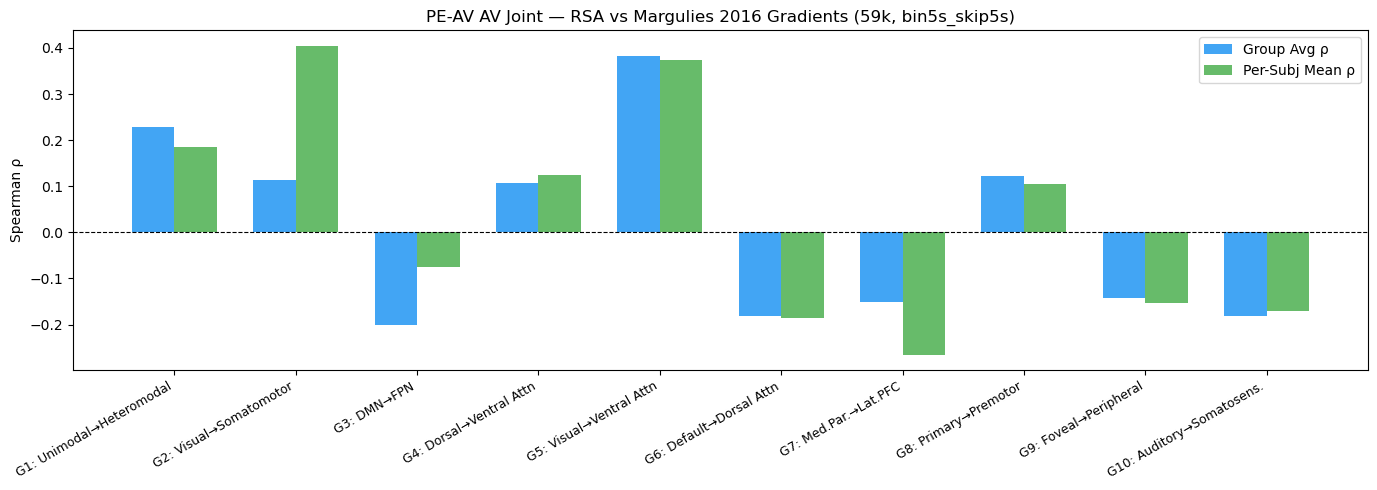

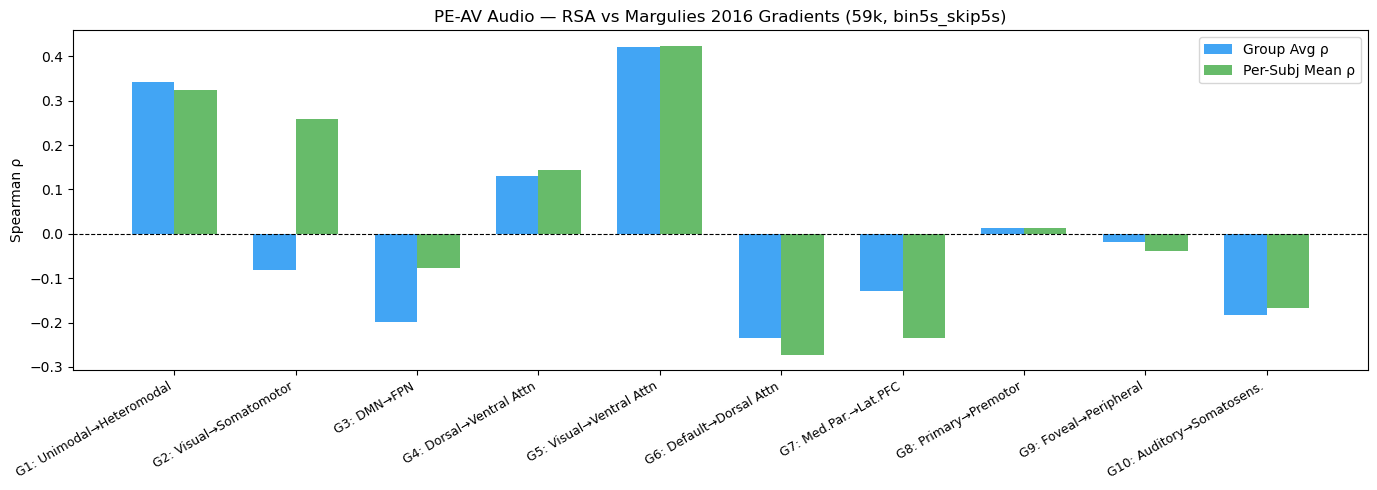

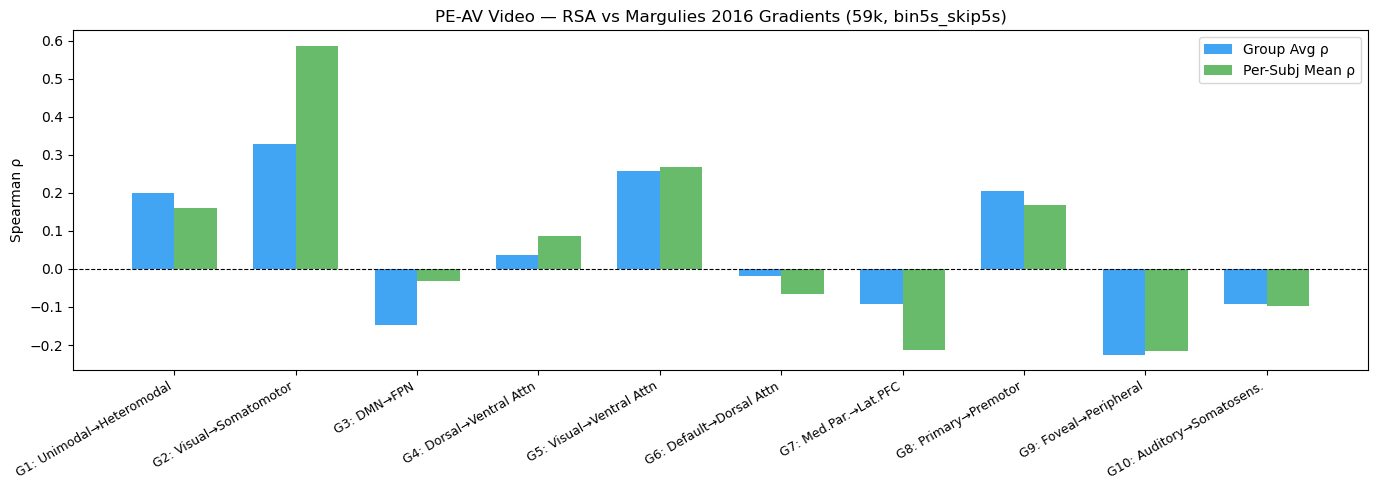

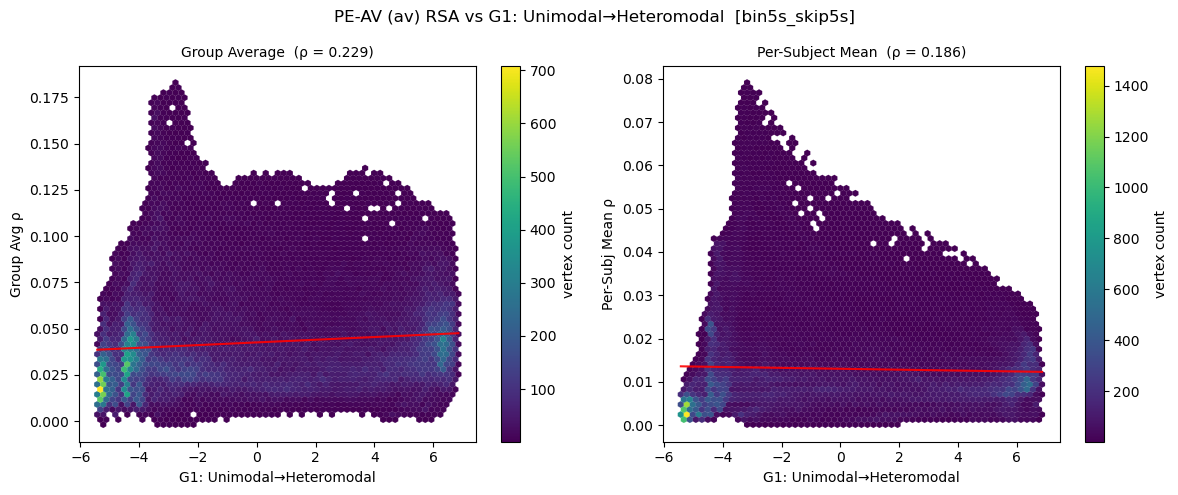

In [2]:
print("Loading/resampling gradients to 59k...")
gradients = {g: load_gradient_59k(g) for g in range(1, 11)}
print("Done.\n")

RSA_LABELS = ['Group Avg ρ', 'Per-Subj Mean ρ']
COLORS     = ['#2196F3', '#4CAF50']

# ── Bar charts: Spearman r of each RSA map vs each gradient ───────────────
for mod_code, mod_label in MODALITIES.items():
    grp_rho, ps_rho = load_rsa_maps(mod_code)
    rsa_maps = [grp_rho, ps_rho]

    corrs = np.zeros((2, 10))
    for ri, rsa_map in enumerate(rsa_maps):
        for g in range(1, 11):
            valid = ~np.isnan(rsa_map) & ~np.isnan(gradients[g])
            r, _ = spearmanr(gradients[g][valid], rsa_map[valid])
            corrs[ri, g - 1] = r

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(10)
    w = 0.35
    for ri, (label, color) in enumerate(zip(RSA_LABELS, COLORS)):
        ax.bar(x + ri * w, corrs[ri], w, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([GRADIENT_LABELS[g] for g in range(1, 11)],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Spearman ρ')
    ax.set_title(f'PE-AV {mod_label} — RSA vs Margulies 2016 Gradients (59k, {BIN_TAG})')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f'gradient_bars_{mod_code}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ── Hexbin scatterplot: Gradient 1 vs PE-AV av (group avg + per-subject) ──
grp_rho_av, ps_rho_av = load_rsa_maps('av')
grad1 = gradients[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'PE-AV (av) RSA vs {GRADIENT_LABELS[1]}  [{BIN_TAG}]', fontsize=12)

hb1 = _hexbin_scatter(axes[0], grad1, grp_rho_av,
                      GRADIENT_LABELS[1], 'Group Avg ρ', 'Group Average')
plt.colorbar(hb1, ax=axes[0], label='vertex count')

hb2 = _hexbin_scatter(axes[1], grad1, ps_rho_av,
                      GRADIENT_LABELS[1], 'Per-Subj Mean ρ', 'Per-Subject Mean')
plt.colorbar(hb2, ax=axes[1], label='vertex count')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'gradient1_hexbin_av.png', dpi=300, bbox_inches='tight')
plt.show()


## Myelin Correlations

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Loading/resampling myelin to 59k...
Myelin: (108441,), nan=463

AV Joint  Group Avg ρ: ρ = -0.103
Audio  Group Avg ρ: ρ = -0.210
Video  Group Avg ρ: ρ = -0.057
AV Joint  Per-Subj Mean ρ: ρ = -0.018
Audio  Per-Subj Mean ρ: ρ = -0.151
Video  Per-Subj Mean ρ: ρ = 0.045


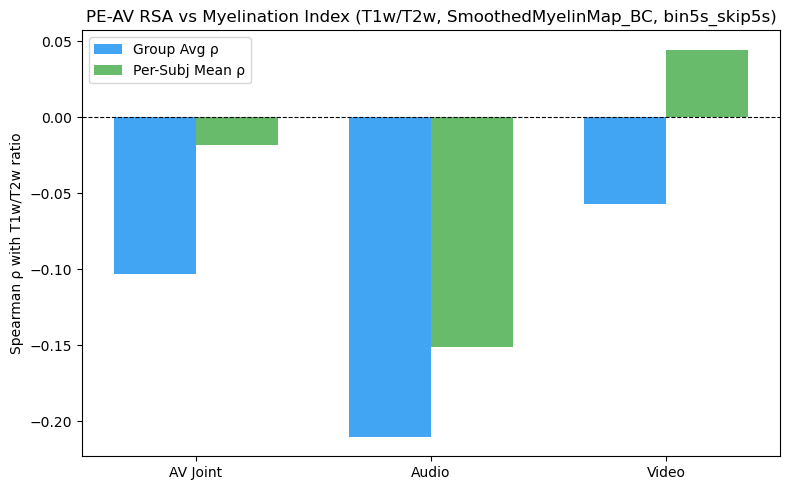

In [3]:
print("Loading/resampling myelin to 59k...")
myelin = load_myelin_59k()
print(f"Myelin: {myelin.shape}, nan={np.isnan(myelin).sum()}\n")

RSA_LABELS = ['Group Avg ρ', 'Per-Subj Mean ρ']
COLORS     = ['#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODALITIES))
w = 0.35

rsa_cache = {}
for mod_code, mod_label in MODALITIES.items():
    rsa_cache[mod_code] = load_rsa_maps(mod_code)

for ri, (label, color) in enumerate(zip(RSA_LABELS, COLORS)):
    vals = []
    for mod_code, mod_label in MODALITIES.items():
        rsa_map = rsa_cache[mod_code][ri]
        valid   = ~np.isnan(rsa_map) & ~np.isnan(myelin)
        r, _    = spearmanr(myelin[valid], rsa_map[valid])
        vals.append(r)
        print(f'{mod_label}  {label}: ρ = {r:.3f}')
    ax.bar(x + ri * w, vals, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + w / 2)
ax.set_xticklabels(list(MODALITIES.values()))
ax.set_ylabel('Spearman ρ with T1w/T2w ratio')
ax.set_title(f'PE-AV RSA vs Myelination Index (T1w/T2w, SmoothedMyelinMap_BC, {BIN_TAG})')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'myelin_rsa_bars.png', dpi=300, bbox_inches='tight')
plt.show()


## Model Comparison Scatterplots (PE-AV Group Avg vs Omni / CAV-MAE-Sync / Myelin)

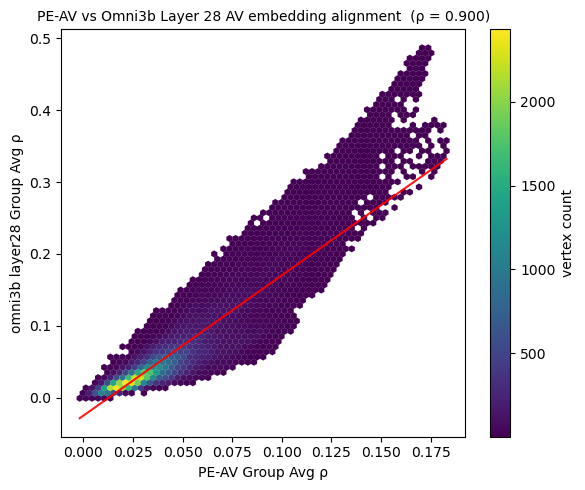

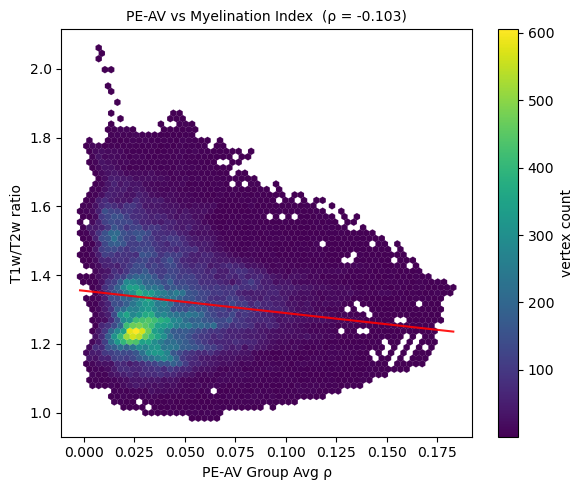

In [4]:
grp_rho_av, _ = load_rsa_maps('av')

omni_rho = load_other_model_rsa(f'omni3b_layer{OMNI_LAYER}_av', modality='av')
# cavmae_rho = load_cavmaesync_59k()
if 'myelin' not in dir():
    print("Loading myelin...")
    myelin = load_myelin_59k()

comparisons = [
    (omni_rho,  f'omni3b layer{OMNI_LAYER+ 1} Group Avg ρ',
     f'PE-AV vs Omni3b Layer {OMNI_LAYER + 1} AV embedding alignment', f'comparison_peav_vs_omni3b_layer{OMNI_LAYER+1}'),
    # (cavmae_rho, 'CAV-MAE-Sync
    #  Group Avg ρ',
    #  'PE-AV vs CAV-MAE-Sync AV embedding alignment', 'comparison_peav_vs_cavmaesync'),
    (myelin,    'T1w/T2w ratio',
     'PE-AV vs Myelination Index', 'comparison_peav_vs_myelin'),
]

for y_data, ylabel, title, fname in comparisons:
    fig, ax = plt.subplots(figsize=(6, 5))
    hb = _hexbin_scatter(ax, grp_rho_av, y_data,
                         'PE-AV Group Avg ρ', ylabel, title)
    plt.colorbar(hb, ax=ax, label='vertex count')
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / f'{fname}.png', dpi=300, bbox_inches='tight')
    plt.show()
